In [114]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [115]:


import pandas as pd

url = "https://jse.amstat.org/datasets/baseball.dat.txt"

# Read only first 17 numeric columns (ignore PlayerName completely)
df = pd.read_table(
    url,
    delim_whitespace=True,
    usecols=list(range(17)),  # salary + performance + flags
    engine="python"
)

df.columns = [
    "Salary","BatAvg","OnBasePct","Runs","Hits","Doubles","Triples",
    "HomeRuns","RBI","Walks","StrikeOuts","StolenBases","Errors",
    "FreeAgencyElig","FreeAgent91_92","ArbitrationElig","Arbitration91_92"
]

df




/var/folders/61/323z6ktx10b5m3jr3rk9s9y40000gn/T/ipykernel_4090/2707000486.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_table is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_table(


,Salary,BatAvg,OnBasePct,Runs,Hits,Doubles,Triples,HomeRuns,RBI,Walks,StrikeOuts,StolenBases,Errors,FreeAgencyElig,FreeAgent91_92,ArbitrationElig,Arbitration91_92
0,2600,0.269,0.335,58,111,17,2,18,66,39,69,0,3,1,1,0,0
1,2500,0.249,0.337,54,115,15,1,17,73,63,116,6,5,1,0,0,0
2,2475,0.260,0.292,59,128,22,7,12,50,23,64,21,21,0,0,1,0
3,2313,0.273,0.346,87,169,28,5,8,58,70,53,3,8,0,0,1,0
4,2175,0.291,0.379,104,170,32,2,26,100,87,89,22,4,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
331,170,0.111,0.138,3,3,0,0,0,1,1,7,0,0,0,0,0,0
332,160,0.264,0.318,24,48,7,0,1,22,15,18,0,7,0,0,0,0
333,142,0.187,0.281,38,50,9,2,15,37,32,98,0,9,0,0,0,0
334,140,0.264,0.270,24,74,16,0,3,27,5,42,0,10,0,0,0,0


In [116]:
features = [
    "Salary","BatAvg","OnBasePct","Runs","Hits",
    "HomeRuns","RBI","Walks","StrikeOuts","StolenBases"
]

X = df[features]


In [117]:
import numpy as np

X["Salary"] = np.log1p(X["Salary"])
X["HomeRuns"] = np.log1p(X["HomeRuns"])
X["RBI"] = np.log1p(X["RBI"])


/var/folders/61/323z6ktx10b5m3jr3rk9s9y40000gn/T/ipykernel_4090/2682031851.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Salary"] = np.log1p(X["Salary"])
/var/folders/61/323z6ktx10b5m3jr3rk9s9y40000gn/T/ipykernel_4090/2682031851.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["HomeRuns"] = np.log1p(X["HomeRuns"])
/var/folders/61/323z6ktx10b5m3jr3rk9s9y40000gn/T/ipykernel_4090/2682031851.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using

In [118]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [119]:
# from sklearn.cluster import KMeans
# import matplotlib.pyplot as plt

# wcss = []

# for k in range(1, 11):
#     kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
#     kmeans.fit(X_scaled)
#     wcss.append(kmeans.inertia_)

# plt.figure()
# plt.plot(range(1, 11), wcss, marker='o')
# plt.xlabel("Number of clusters (k)")
# plt.ylabel("WCSS")
# plt.title("Elbow Method for Optimal k")
# plt.show()


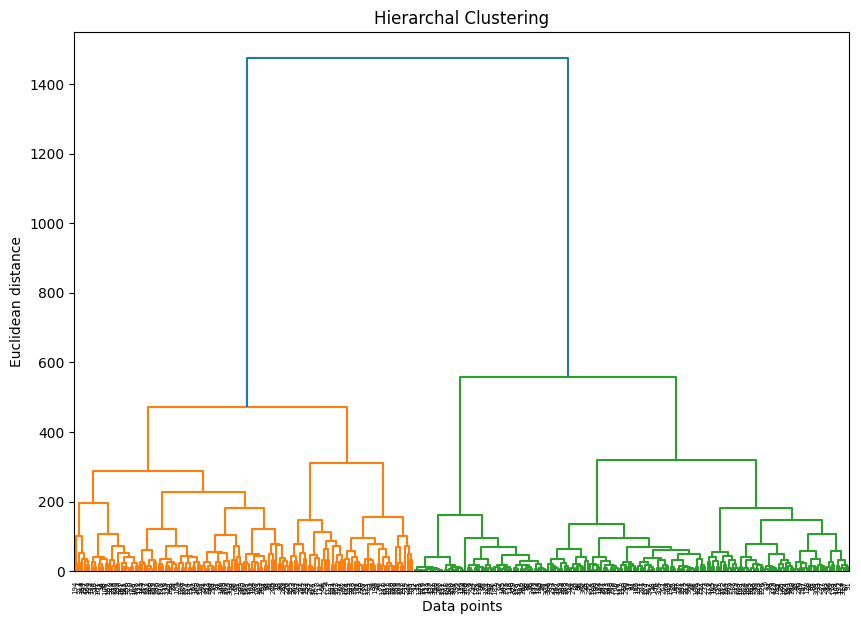

In [120]:
plt.figure(figsize=(10,7))
plt.title("Hierarchal Clustering")
dendrogram(linkage(X, method='ward'))
plt.xlabel("Data points")
plt.ylabel("Euclidean distance")
plt.show()

In [121]:
hc = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
labels=hc.fit_predict(X_scaled)
print("Labels:", labels)

Labels: [0 0 0 0 0 0 1 1 0 1 1 1 1 0 0 0 0 1 1 0 0 1 1 0 0 0 0 0 1 0 1 0 1 0 1 1 1
 0 0 0 0 0 1 0 1 1 1 0 1 1 0 0 0 1 1 0 0 1 1 1 1 0 1 1 0 0 0 0 0 0 0 1 0 0
 0 1 1 0 0 0 0 0 1 0 0 1 1 0 1 1 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 1 0 0 0 1
 0 0 0 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 1 0 0 1 1 1 1 1 0 0 0 0 1 1 1 1 1 1 1
 1 1 1 0 0 0 0 0 1 0 1 1 0 0 1 1 0 0 0 0 0 0 0 0 0 1 1 0 1 1 1 1 1 1 0 0 1
 1 1 0 1 1 0 0 0 0 0 0 0 1 1 0 0 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0
 0 1 0 0 1 1 1 0 0 0 0 0 0 1 1 1 1 1 0 1 0 0 0 1 1 1 1 1 1 0 0 0 0 0 0 0 1
 0 0 1 1 1 1 1 1 0 0 0 1 0 1 0 1 1 1 1 0 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0
 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 1 0 1 1 1 0 0 0 0 0 1 0 0 0 1 1 1 1
 0 1 1]


In [122]:
optimal_k = 2  # (example – use what your elbow suggests)
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add clusters to dataframe
# df["Cluster"] = cluster_labels
df["Cluster"] = labels


In [123]:
X_knn = X_scaled        # features
y_knn = df["Cluster"]  # cluster labels


In [124]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_knn,
    y_knn,
    test_size=0.2,
    random_state=42,
    stratify=y_knn
)


In [125]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=5,
    weights="distance",
    metric="euclidean"
)

knn.fit(X_train, y_train)




,n_neighbors,5
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'euclidean'
,metric_params,None
,n_jobs,None


In [126]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.9852941176470589
[[38  0]
 [ 1 29]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        38
           1       1.00      0.97      0.98        30

    accuracy                           0.99        68
   macro avg       0.99      0.98      0.99        68
weighted avg       0.99      0.99      0.99        68



In [127]:

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))



Accuracy: 0.9852941176470589
[[38  0]
 [ 1 29]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        38
           1       1.00      0.97      0.98        30

    accuracy                           0.99        68
   macro avg       0.99      0.98      0.99        68
weighted avg       0.99      0.99      0.99        68



In [128]:
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# y_pred = knn.predict(X_test_scaled)

# print("Accuracy:", accuracy_score(y_test, y_pred))
# print(confusion_matrix(y_test, y_pred))
# print(classification_report(y_test, y_pred))
